# Plots — N=2, |++⟩, Ideal Homodyne (η₁=η₂=1)

**Osservabili:** Concurrence, ξ²_KU (Kitagawa–Ueda), ξ²_WIN (Wineland)  
**Angoli:** tutte le 4 combinazioni (φ₁, φ₂) ∈ {0, π/2}²  
**Struttura del notebook:**  
1. **Celle di setup** — operatori, e_ops, parametri  
2. **Celle di simulazione** — una per coppia di angoli, salvano i dati in `data_XX`  
3. **Cella di consolidamento** — assembla tutto in `ALL_DATA`  
4. **Celle di plot** — una per grafico, leggono solo da `ALL_DATA`

> ⚠️ Runnare prima tutte le celle di simulazione (§ Simulazioni), poi i plot possono essere rigenerati indipendentemente.

In [23]:
# ── Setup: Imports & stile ─────────────────────────────────────────────
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# ── Stile — identico al QFI notebook ──────────────────────────────────────────
# text.usetex=True richiede MiKTeX/TeX Live installato.
# Se non disponibile: USETEX=False -- il mathtext di matplotlib
# con Computer Modern produce un output visivamente identico.
USETEX = True
plt.rcParams["text.usetex"] = USETEX
plt.rcParams.update({
    "mathtext.fontset":   "cm",
    "font.family":        "serif",
    "font.size":          13,
    "axes.unicode_minus": False,
})

# ── Cartella di output ─────────────────────────────────────────────
SAVE_FIGS = True    # True -> salva PNG + PDF in OUT_DIR
OUT_DIR   = Path("Graphs") / "Plots_N2_PlusPlus_IdealHomo"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup ok. OUT_DIR:", OUT_DIR.resolve())


Setup ok. OUT_DIR: C:\Users\staka\OneDrive\Desktop\Figlio\Stochastic_Master_Thesis\Codes\Graphs\Plots_N2_PlusPlus_IdealHomo


In [24]:
# ── Setup: Operatori quantistici N=2 e stato iniziale |++⟩ ───────────────────
from qutip import (
    basis, expect, ket2dm, qeye,
    sigmax, sigmay, sigmaz,
    
    smesolve, tensor, variance,
)

# Path verso main_SLURM.py (contiene xi_KU_solver, xi_WIN_solver, angle_to_tex)
CODE_DIR = Path(".").resolve()
for candidate in [CODE_DIR, CODE_DIR.parent]:
    if (candidate / "main_SLURM.py").exists():
        CODE_DIR = candidate
        break
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from main_SLURM import xi_KU_solver, xi_WIN_solver, angle_to_tex

# ── Base e stato iniziale ─────────────────────────────────────────────────────
gnd        = basis(2, 0)
exc        = basis(2, 1)
plus_state = (gnd + exc).unit()
psi0       = tensor(plus_state, plus_state)   # |++⟩
rho0       = ket2dm(psi0)

# ── Operatori di spin collettivi ──────────────────────────────────────────────
I_2 = qeye(2)
J_x = 0.5 * (tensor(sigmax(), I_2) + tensor(I_2, sigmax()))
J_y = 0.5 * (tensor(sigmay(), I_2) + tensor(I_2, sigmay()))
J_z = 0.5 * (tensor(sigmaz(), I_2) + tensor(I_2, sigmaz()))

# ── Canali di misura: C_+ (simmetrico) e C_- (antisimmetrico) ─────────────────
Cp     = np.sqrt(0.5) * (tensor(sigmaz(), I_2) + tensor(I_2, sigmaz()))
Cm     = np.sqrt(0.5) * (tensor(sigmaz(), I_2) - tensor(I_2, sigmaz()))
H_free = 0.0 * J_z   # nessuna evoluzione coerente

print("Stato |++⟩, dims:", psi0.dims, "| norma:", float(psi0.norm()))
print("xi_KU_solver e xi_WIN_solver importati da main_SLURM.")

Stato |++⟩, dims: [[2, 2], [1]] | norma: 0.9999999999999998
xi_KU_solver e xi_WIN_solver importati da main_SLURM.


In [25]:
# ── Setup: e_ops callables per smesolve ───────────────────────────────────────
# QuTiP valuta questi callable con firma (t, state) ad ogni time step,
# salvando solo lo scalare senza tenere in memoria la storia completa degli stati.

# ── Concurrence (Wootters) ────────────────────────────────────────────────────
try:
    from qutip import concurrence as _qtp_concurrence
    def conc_eop(t, state):
        return float(_qtp_concurrence(state))
except ImportError:
    _SYSY = tensor(sigmay(), sigmay())
    def conc_eop(t, state):
        if state.isket:
            c = state.full().flatten()
            return float(2.0 * np.abs(c[0] * c[3] - c[1] * c[2]))
        rho_tilde = (state * _SYSY) * (state.conj() * _SYSY)
        evals     = np.sort(np.abs(np.real(rho_tilde.eigenenergies())))
        sqrt_ev   = np.sqrt(evals)
        return float(max(0.0, sqrt_ev[3] - sqrt_ev[2] - sqrt_ev[1] - sqrt_ev[0]))

# ── ξ²_KU (Kitagawa–Ueda) ────────────────────────────────────────────────────
def xi_ku_eop(t, state):
    return float(xi_KU_solver(t, state, N=2))

# ── ξ²_WIN (Wineland) ────────────────────────────────────────────────────────
def xi_win_eop(t, state):
    return float(xi_WIN_solver(t, state, N=2))

E_OPS   = [conc_eop, xi_ku_eop, xi_win_eop]

print("e_ops pronti: concurrence, xi_KU, xi_WIN")

e_ops pronti: concurrence, xi_KU, xi_WIN


In [26]:
# ── Setup: Parametri di simulazione ─────────────────────────────────────────
GAMMA  = 1.0
T_END  = 5.0
DT     = 0.005   # Milstein (ordine 1.0): dt=0.01 accurato quanto Euler dt=0.001
NTRAJ  = 500      # Milstein è ~10x più veloce per step: 500 traj ora fattibili
ETA_1  = 1.0
ETA_2  = 1.0

N_TIMES = int(round(T_END / DT)) + 1
times   = np.linspace(0.0, T_END, N_TIMES)

# Asse x adimensionale: t / T_1  con  T_1 = 1/gamma
T1 = 1.0 / GAMMA
x  = times / T1      # con gamma=1 coincide con times; label: t/T_1

# ── 4 combinazioni di angoli ──────────────────────────────────────────────────
PHI_PAIRS  = [
    (0.0,         0.0),
    (0.0,         np.pi / 2),
    (np.pi / 2,   0.0),
    (np.pi / 2,   np.pi / 2),
]
PHI_LABELS = [
    r"$\phi_1 = 0,\; \phi_2 = 0$",
    r"$\phi_1 = 0,\; \phi_2 = \pi/2$",
    r"$\phi_1 = \pi/2,\; \phi_2 = 0$",
    r"$\phi_1 = \pi/2,\; \phi_2 = \pi/2$",
]
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

def build_ops(phi1, phi2, eta1=ETA_1, eta2=ETA_2, gamma=GAMMA):
    c_ops, sc_ops = [], []
    for eta, phi, C in [(eta1, phi1, Cp), (eta2, phi2, Cm)]:
        base = np.sqrt(gamma) * np.exp(1j * phi) * C
        if eta < 1.0:
            c_ops.append(np.sqrt(1.0 - eta) * base)
        if eta > 0.0:
            sc_ops.append(np.sqrt(eta) * base)
    return c_ops, sc_ops

SME_OPTIONS = {"keep_runs_results": True, "map": "serial", "store_measurement": False, "method": "milstein"}

print(f"T_END={T_END}, DT={DT}, N_TIMES={N_TIMES}, ntraj={NTRAJ}")
print(f"T1={T1:.2f},  x in [{x[0]:.2f}, {x[-1]:.2f}]")


T_END=5.0, DT=0.005, N_TIMES=1001, ntraj=500
T1=1.00,  x in [0.00, 5.00]


## Simulazioni

Ogni cella esegue una simulazione SME per una coppia (φ₁, φ₂) e salva i risultati in un dizionario `data_XX`.  
Re-runnare una singola cella aggiorna solo quei dati; i plot rimangono invariati finché non si esegue la cella di consolidamento.

In [27]:
# ── Simulazione A: (φ₁=0, φ₂=0) ─────────────────────────────────────────────
phi1_A, phi2_A = PHI_PAIRS[0]
c_ops_A, sc_ops_A = build_ops(phi1_A, phi2_A)

print(f"Avvio simulazione (φ₁={phi1_A:.4f}, φ₂={phi2_A:.4f}), ntraj={NTRAJ}...")
t0 = time.time()
sol_A = smesolve(
    H_free, rho0, times,
    c_ops=c_ops_A, sc_ops=sc_ops_A,
    heterodyne=False,
    ntraj=NTRAJ,
    e_ops=E_OPS,
    options=SME_OPTIONS,
)
dt_A = time.time() - t0
print(f"Completata in {dt_A:.1f}s")

# sol.runs_expect[i_eop] è una lista di ntraj array 1D di lunghezza N_TIMES
# np.array(...) → shape (ntraj, N_TIMES)
data_00 = {
    "phi1":     phi1_A,
    "phi2":     phi2_A,
    "label":    PHI_LABELS[0],
    "color":    COLORS[0],
    "conc":     np.real(np.array(sol_A.runs_expect[0])),   # (ntraj, N_TIMES)
    "xi_ku":    np.real(np.array(sol_A.runs_expect[1])),
    "xi_win":   np.real(np.array(sol_A.runs_expect[2])),
}
del sol_A
print("Dati salvati in data_00.")

Avvio simulazione (φ₁=0.0000, φ₂=0.0000), ntraj=500...
10.0%. Run time:  58.65s. Est. time left: 00:00:08:47
20.0%. Run time: 115.59s. Est. time left: 00:00:07:42
30.0%. Run time: 171.29s. Est. time left: 00:00:06:39
40.0%. Run time: 237.28s. Est. time left: 00:00:05:55
50.0%. Run time: 291.30s. Est. time left: 00:00:04:51
60.0%. Run time: 348.00s. Est. time left: 00:00:03:51
70.0%. Run time: 405.90s. Est. time left: 00:00:02:53
80.0%. Run time: 463.62s. Est. time left: 00:00:01:55
90.0%. Run time: 521.72s. Est. time left: 00:00:00:57
100.0%. Run time: 578.41s. Est. time left: 00:00:00:00
Total run time: 579.72s
Completata in 579.8s
Dati salvati in data_00.


In [28]:
# ── Simulazione B: (φ₁=0, φ₂=π/2) ──────────────────────────────────────────
phi1_B, phi2_B = PHI_PAIRS[1]
c_ops_B, sc_ops_B = build_ops(phi1_B, phi2_B)

print(f"Avvio simulazione (φ₁={phi1_B:.4f}, φ₂={phi2_B:.4f}), ntraj={NTRAJ}...")
t0 = time.time()
sol_B = smesolve(
    H_free, rho0, times,
    c_ops=c_ops_B, sc_ops=sc_ops_B,
    heterodyne=False,
    ntraj=NTRAJ,
    e_ops=E_OPS,
    options=SME_OPTIONS,
)
dt_B = time.time() - t0
print(f"Completata in {dt_B:.1f}s")

data_0h = {
    "phi1":     phi1_B,
    "phi2":     phi2_B,
    "label":    PHI_LABELS[1],
    "color":    COLORS[1],
    "conc":     np.real(np.array(sol_B.runs_expect[0])),
    "xi_ku":    np.real(np.array(sol_B.runs_expect[1])),
    "xi_win":   np.real(np.array(sol_B.runs_expect[2])),
}
del sol_B
print("Dati salvati in data_0h.")

Avvio simulazione (φ₁=0.0000, φ₂=1.5708), ntraj=500...
10.0%. Run time:  52.56s. Est. time left: 00:00:07:53
20.0%. Run time: 105.63s. Est. time left: 00:00:07:02
30.0%. Run time: 159.37s. Est. time left: 00:00:06:11
40.0%. Run time: 212.80s. Est. time left: 00:00:05:19
50.0%. Run time: 274.95s. Est. time left: 00:00:04:34
60.0%. Run time: 335.75s. Est. time left: 00:00:03:43
70.0%. Run time: 397.37s. Est. time left: 00:00:02:50
80.0%. Run time: 458.28s. Est. time left: 00:00:01:54
90.0%. Run time: 519.72s. Est. time left: 00:00:00:57
100.0%. Run time: 583.26s. Est. time left: 00:00:00:00
Total run time: 584.56s
Completata in 584.6s
Dati salvati in data_0h.


In [29]:
# ── Simulazione C: (φ₁=π/2, φ₂=0) ──────────────────────────────────────────
phi1_C, phi2_C = PHI_PAIRS[2]
c_ops_C, sc_ops_C = build_ops(phi1_C, phi2_C)

print(f"Avvio simulazione (φ₁={phi1_C:.4f}, φ₂={phi2_C:.4f}), ntraj={NTRAJ}...")
t0 = time.time()
sol_C = smesolve(
    H_free, rho0, times,
    c_ops=c_ops_C, sc_ops=sc_ops_C,
    heterodyne=False,
    ntraj=NTRAJ,
    e_ops=E_OPS,
    options=SME_OPTIONS,
)
dt_C = time.time() - t0
print(f"Completata in {dt_C:.1f}s")

data_h0 = {
    "phi1":     phi1_C,
    "phi2":     phi2_C,
    "label":    PHI_LABELS[2],
    "color":    COLORS[2],
    "conc":     np.real(np.array(sol_C.runs_expect[0])),
    "xi_ku":    np.real(np.array(sol_C.runs_expect[1])),
    "xi_win":   np.real(np.array(sol_C.runs_expect[2])),
}
del sol_C
print("Dati salvati in data_h0.")

Avvio simulazione (φ₁=1.5708, φ₂=0.0000), ntraj=500...
10.0%. Run time:  61.59s. Est. time left: 00:00:09:14
20.0%. Run time: 123.37s. Est. time left: 00:00:08:13
30.0%. Run time: 185.33s. Est. time left: 00:00:07:12
40.0%. Run time: 246.98s. Est. time left: 00:00:06:10
50.0%. Run time: 308.45s. Est. time left: 00:00:05:08
60.0%. Run time: 370.34s. Est. time left: 00:00:04:06
70.0%. Run time: 432.86s. Est. time left: 00:00:03:05
80.0%. Run time: 492.94s. Est. time left: 00:00:02:03
90.0%. Run time: 553.12s. Est. time left: 00:00:01:01
100.0%. Run time: 618.19s. Est. time left: 00:00:00:00
Total run time: 619.30s
Completata in 619.3s
Dati salvati in data_h0.


In [30]:
# ── Simulazione D: (φ₁=π/2, φ₂=π/2) ────────────────────────────────────────
phi1_D, phi2_D = PHI_PAIRS[3]
c_ops_D, sc_ops_D = build_ops(phi1_D, phi2_D)

print(f"Avvio simulazione (φ₁={phi1_D:.4f}, φ₂={phi2_D:.4f}), ntraj={NTRAJ}...")
t0 = time.time()
sol_D = smesolve(
    H_free, rho0, times,
    c_ops=c_ops_D, sc_ops=sc_ops_D,
    heterodyne=False,
    ntraj=NTRAJ,
    e_ops=E_OPS,
    options=SME_OPTIONS,
)
dt_D = time.time() - t0
print(f"Completata in {dt_D:.1f}s")

data_hh = {
    "phi1":     phi1_D,
    "phi2":     phi2_D,
    "label":    PHI_LABELS[3],
    "color":    COLORS[3],
    "conc":     np.real(np.array(sol_D.runs_expect[0])),
    "xi_ku":    np.real(np.array(sol_D.runs_expect[1])),
    "xi_win":   np.real(np.array(sol_D.runs_expect[2])),
}
del sol_D
print("Dati salvati in data_hh.")

Avvio simulazione (φ₁=1.5708, φ₂=1.5708), ntraj=500...
10.0%. Run time:  56.25s. Est. time left: 00:00:08:26
20.0%. Run time: 137.74s. Est. time left: 00:00:09:10
30.0%. Run time: 199.44s. Est. time left: 00:00:07:45
40.0%. Run time: 251.99s. Est. time left: 00:00:06:17
50.0%. Run time: 307.84s. Est. time left: 00:00:05:07
60.0%. Run time: 362.08s. Est. time left: 00:00:04:01
70.0%. Run time: 414.60s. Est. time left: 00:00:02:57
80.0%. Run time: 466.90s. Est. time left: 00:00:01:56
90.0%. Run time: 518.99s. Est. time left: 00:00:00:57
100.0%. Run time: 572.22s. Est. time left: 00:00:00:00
Total run time: 573.34s
Completata in 588.5s
Dati salvati in data_hh.


In [31]:
# ── Consolidamento: assembla tutti i dati in ALL_DATA ─────────────────────────
# Runnare questa cella ogni volta che si rieseguono le simulazioni.

ALL_DATA = [data_00, data_0h, data_h0, data_hh]

print(f"ALL_DATA assemblato: {len(ALL_DATA)} dataset")
for d in ALL_DATA:
    print(
        f"  {d['label']:35s}  "
        f"conc shape={d['conc'].shape}  "
        f"C_max(mean)={d['conc'].mean(axis=0).max():.3f}  "
        f"xi_ku_min(mean)={d['xi_ku'].mean(axis=0).min():.3f}"
    )

ALL_DATA assemblato: 4 dataset
  $\phi_1 = 0,\; \phi_2 = 0$           conc shape=(500, 1001)  C_max(mean)=0.000  xi_ku_min(mean)=0.467
  $\phi_1 = 0,\; \phi_2 = \pi/2$       conc shape=(500, 1001)  C_max(mean)=0.530  xi_ku_min(mean)=0.468
  $\phi_1 = \pi/2,\; \phi_2 = 0$       conc shape=(500, 1001)  C_max(mean)=0.504  xi_ku_min(mean)=0.001
  $\phi_1 = \pi/2,\; \phi_2 = \pi/2$   conc shape=(500, 1001)  C_max(mean)=0.000  xi_ku_min(mean)=0.427


## Grafici

Ogni cella produce un grafico indipendente leggendo da `ALL_DATA`.  
Modificare titolo, assi, colori in una cella non influenza gli altri grafici.  
Per salvare i file, impostare `SAVE_FIGS = True` nella cella di setup.

In [33]:
# ── PLOT 1: Concurrence — spaghetti 2x2 ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

for ax, d in zip(axes.flat, ALL_DATA):
    for traj in d["conc"]:
        ax.plot(x, traj, color=d["color"], alpha=0.35, linewidth=0.8)
    ax.plot(x, d["conc"].mean(axis=0),
            color="black", linewidth=2.2, zorder=5,
            label=r"$\langle \mathcal{C} \rangle$")
    ax.axhline(1.0, color="grey", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.set_title(d["label"], fontsize=12)
    ax.set_ylim(-0.02, 1.08)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.legend(fontsize=12, loc="upper right")
    ax.grid(True, linestyle=":", alpha=0.6)

for ax in axes[1]:
    ax.set_xlabel(r"$t / T_1$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"\mathcal{C}$")

plt.suptitle(
    rf"$ Ideal homodyne, |{{+}}{{+}}\rangle$,  ($\eta_1 = \eta_2 = 1$, ntraj$={NTRAJ}$)",
    fontsize=13
)

if SAVE_FIGS:
    fig.savefig(OUT_DIR / "conc_spaghetti_2x2.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

RuntimeError: latex was not able to process the following string:
b'\\\\mathcal{C}$'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpcrt4dj9z 87d10b7c78b9ee2bf28e692962d125c53b79026064f0237ddaf0025840aac11e.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./87d10b7c78b9ee2bf28e692962d125c53b79026064f0237ddaf0025840aac11e.tex
LaTeX2e <2025-11-01>
L3 programming layer <2025-12-29>
(c:/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(c:/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(c:/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(c:/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(c:/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(c:/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(c:/texlive/2025/tex

Error in callback <function _draw_all_if_interactive at 0x000002089AEA85E0> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'\\\\mathcal{C}$'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpl4v1zcr9 87d10b7c78b9ee2bf28e692962d125c53b79026064f0237ddaf0025840aac11e.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./87d10b7c78b9ee2bf28e692962d125c53b79026064f0237ddaf0025840aac11e.tex
LaTeX2e <2025-11-01>
L3 programming layer <2025-12-29>
(c:/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(c:/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(c:/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(c:/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(c:/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(c:/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(c:/texlive/2025/tex

RuntimeError: latex was not able to process the following string:
b'\\\\mathcal{C}$'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp_vw_gs7h 87d10b7c78b9ee2bf28e692962d125c53b79026064f0237ddaf0025840aac11e.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./87d10b7c78b9ee2bf28e692962d125c53b79026064f0237ddaf0025840aac11e.tex
LaTeX2e <2025-11-01>
L3 programming layer <2025-12-29>
(c:/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(c:/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(c:/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(c:/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(c:/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(c:/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(c:/texlive/2025/tex

<Figure size 1400x800 with 4 Axes>

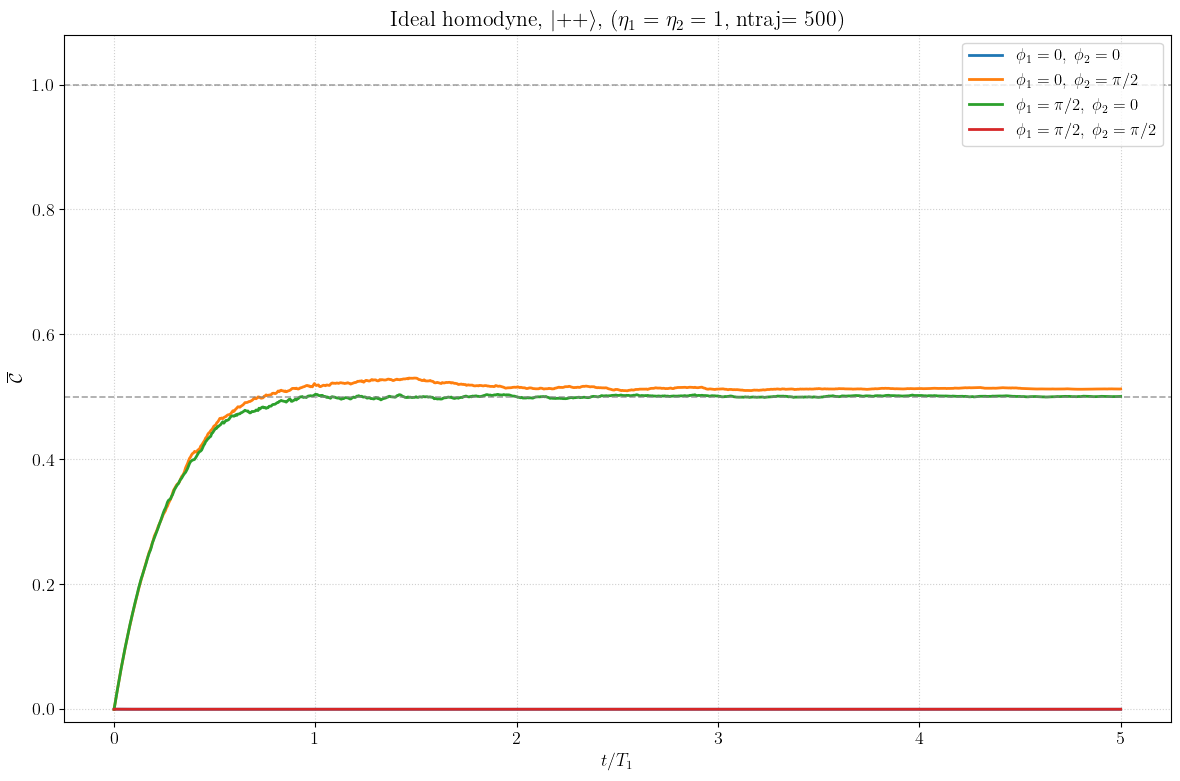

In [34]:
# ── PLOT 2: Concurrence — medie d'insieme a confronto ─────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

for d in ALL_DATA:
    ax.plot(x, d["conc"].mean(axis=0),
            color=d["color"], linewidth=2.0, label=d["label"])

ax.axhline(1.0, color="grey", linestyle="--", linewidth=1.2, alpha=0.7)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_xlabel(r"$t / T_1$")
ax.set_ylabel(r"$ \overline{\mathcal{C}} $")
ax.set_ylim(-0.02, 1.08)
ax.set_title(rf"Ideal homodyne, $|{{+}}{{+}}\rangle$, ($\eta_1 = \eta_2 = 1$, ntraj$={NTRAJ}$)")
ax.legend(fontsize=12)
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "conc_means_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


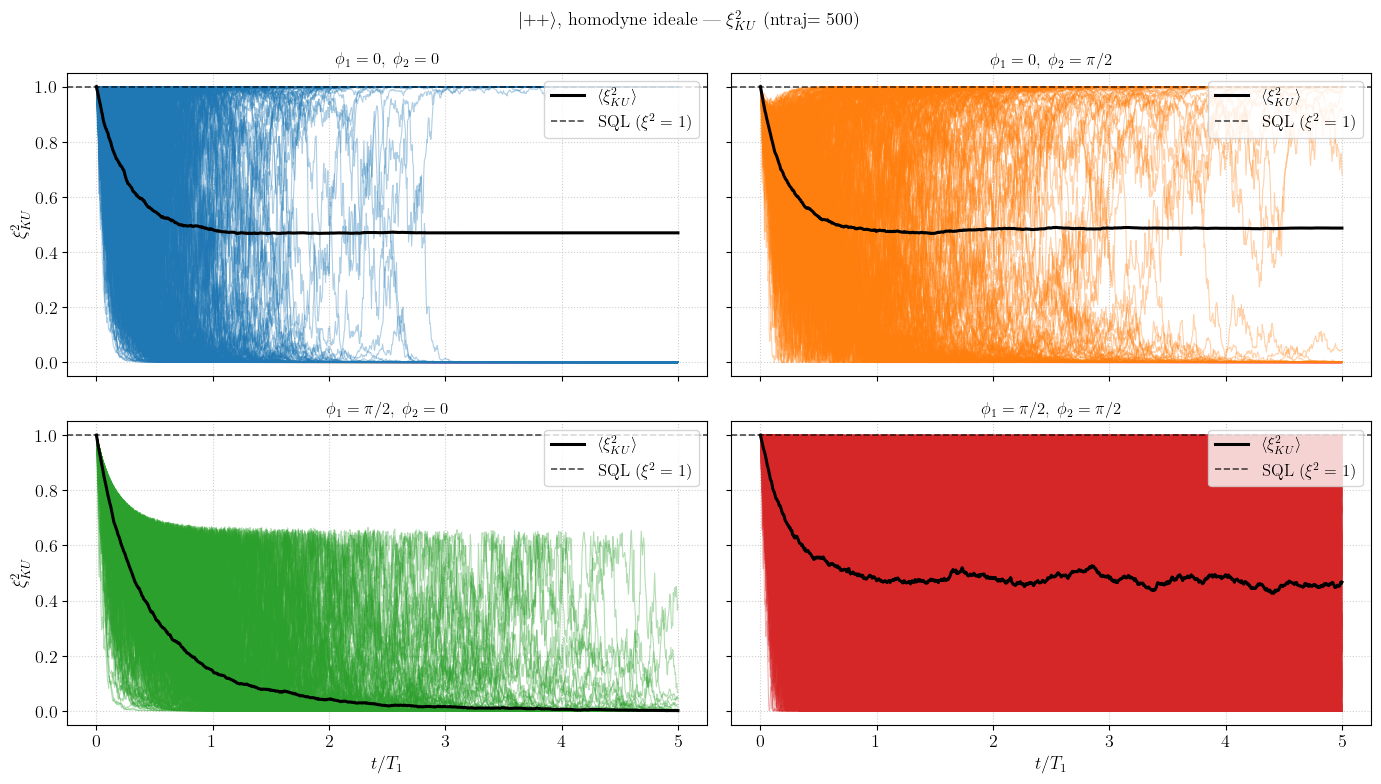

In [35]:
# ── PLOT 3: xi^2_KU — spaghetti 2x2 ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

for ax, d in zip(axes.flat, ALL_DATA):
    for traj in d["xi_ku"]:
        ax.plot(x, traj, color=d["color"], alpha=0.35, linewidth=0.8)
    ax.plot(x, d["xi_ku"].mean(axis=0),
            color="black", linewidth=2.2, zorder=5,
            label=r"$\langle \xi^2_{KU} \rangle$")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
               label=r"SQL ($\xi^2 = 1$)")
    ax.set_title(d["label"], fontsize=12)
    ax.legend(fontsize=12, loc="upper right")
    ax.grid(True, linestyle=":", alpha=0.6)

for ax in axes[1]:
    ax.set_xlabel(r"$t / T_1$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\xi^2_{KU}$")

plt.suptitle(
    rf"$|{{+}}{{+}}\rangle$, homodyne ideale --- $\xi^2_{{KU}}$ (ntraj$={NTRAJ}$)",
    fontsize=13
)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "xi_ku_spaghetti_2x2.png", dpi=300, bbox_inches="tight")
plt.show()


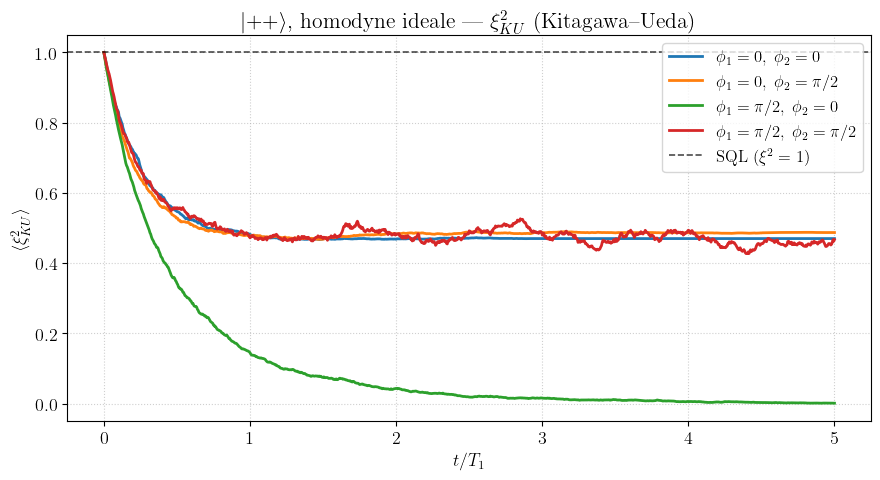

In [36]:
# ── PLOT 4: xi^2_KU — medie d'insieme a confronto ───────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for d in ALL_DATA:
    ax.plot(x, d["xi_ku"].mean(axis=0),
            color=d["color"], linewidth=2.0, label=d["label"])

ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label=r"SQL ($\xi^2 = 1$)")
ax.set_xlabel(r"$t / T_1$")
ax.set_ylabel(r"$\langle \xi^2_{KU} \rangle$")
ax.set_title(rf"$|{{+}}{{+}}\rangle$, homodyne ideale --- $\xi^2_{{KU}}$ (Kitagawa--Ueda)")
ax.legend(fontsize=12)
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "xi_ku_means_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


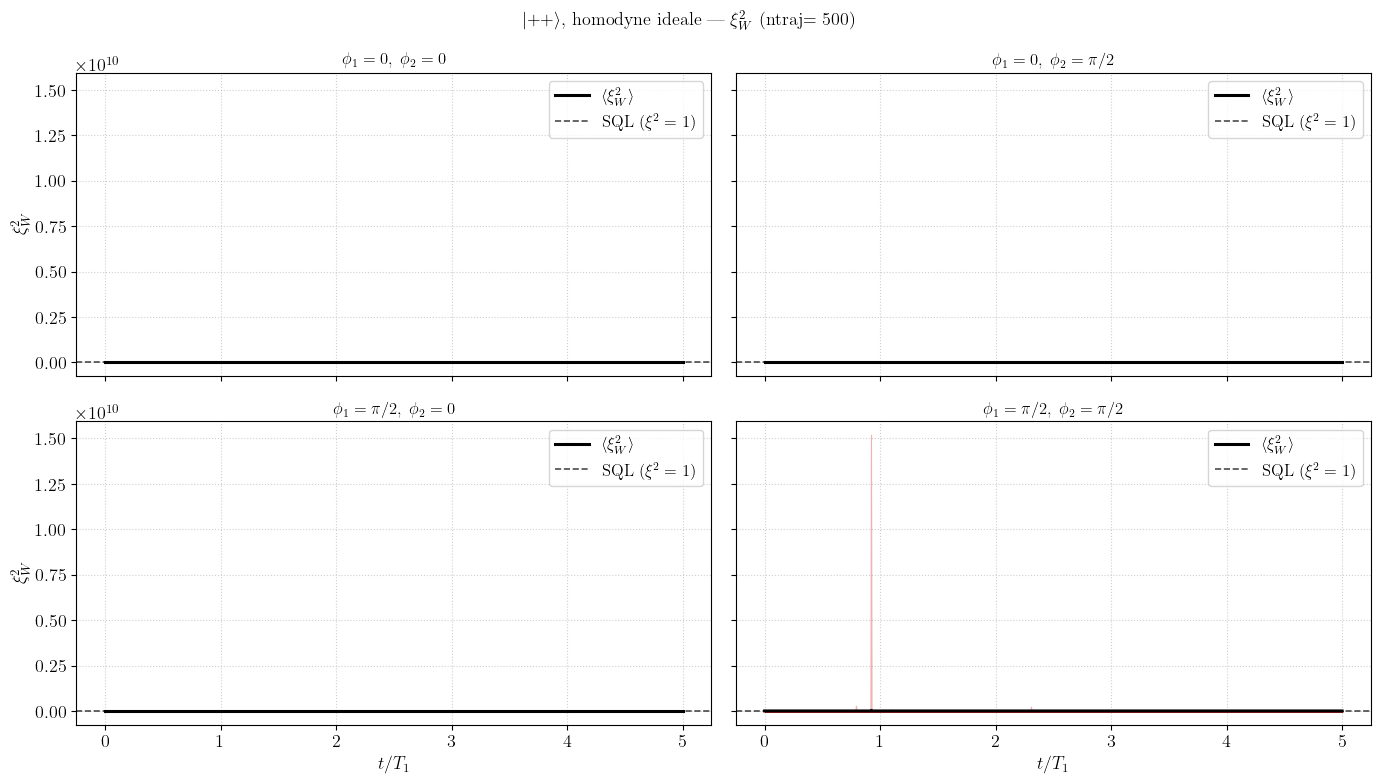

In [37]:
# ── PLOT 5: xi^2_W — spaghetti 2x2 ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

for ax, d in zip(axes.flat, ALL_DATA):
    for traj in d["xi_win"]:
        ax.plot(x, traj, color=d["color"], alpha=0.35, linewidth=0.8)
    ax.plot(x, d["xi_win"].mean(axis=0),
            color="black", linewidth=2.2, zorder=5,
            label=r"$\langle \xi^2_{W} \rangle$")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
               label=r"SQL ($\xi^2 = 1$)")
    ax.set_title(d["label"], fontsize=12)
    ax.legend(fontsize=12, loc="upper right")
    ax.grid(True, linestyle=":", alpha=0.6)

for ax in axes[1]:
    ax.set_xlabel(r"$t / T_1$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\xi^2_{W}$")

plt.suptitle(
    rf"$|{{+}}{{+}}\rangle$, homodyne ideale --- $\xi^2_{{W}}$ (ntraj$={NTRAJ}$)",
    fontsize=13
)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "xi_win_spaghetti_2x2.png", dpi=300, bbox_inches="tight")
plt.show()


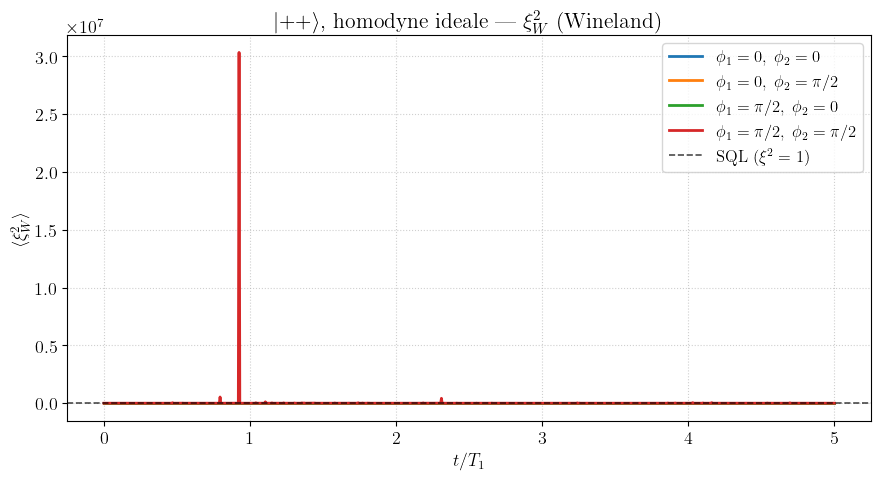

In [38]:
# ── PLOT 6: xi^2_W — medie d'insieme a confronto ────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for d in ALL_DATA:
    ax.plot(x, d["xi_win"].mean(axis=0),
            color=d["color"], linewidth=2.0, label=d["label"])

ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label=r"SQL ($\xi^2 = 1$)")
ax.set_xlabel(r"$t / T_1$")
ax.set_ylabel(r"$\langle \xi^2_{W} \rangle$")
ax.set_title(rf"$|{{+}}{{+}}\rangle$, homodyne ideale --- $\xi^2_{{W}}$ (Wineland)")
ax.legend(fontsize=12)
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "xi_win_means_comparison.png", dpi=300, bbox_inches="tight")



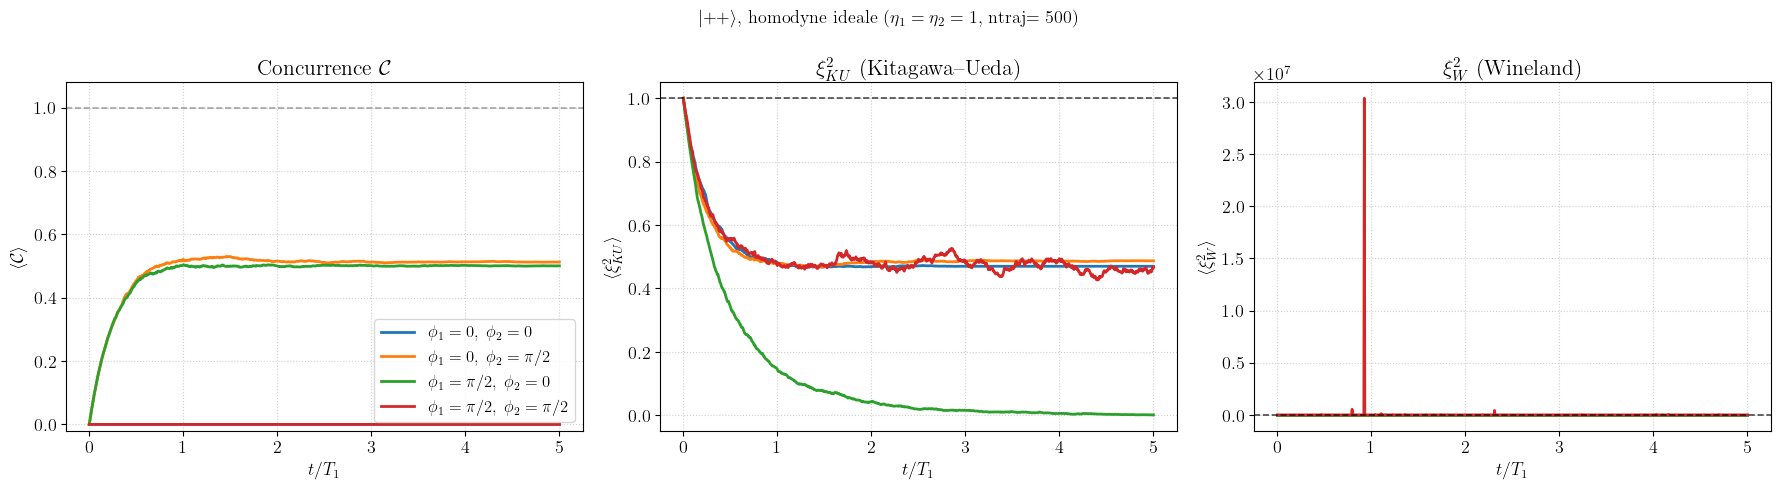

In [39]:
# ── PLOT 7: Pannello riassuntivo 1x3 — C, xi^2_KU, xi^2_W ──────────────────
# Figura tesi-ready: una colonna per osservabile, 4 curve per coppia di angoli.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

obs_keys = ["conc",    "xi_ku",       "xi_win"]
ylabels  = [
    r"$\langle \mathcal{C} \rangle$",
    r"$\langle \xi^2_{KU} \rangle$",
    r"$\langle \xi^2_{W} \rangle$",
]
titles   = [
    r"Concurrence $\mathcal{C}$",
    r"$\xi^2_{KU}$ (Kitagawa--Ueda)",
    r"$\xi^2_{W}$ (Wineland)",
]

for ax, key, ylabel, title in zip(axes, obs_keys, ylabels, titles):
    for d in ALL_DATA:
        ax.plot(x, d[key].mean(axis=0),
                color=d["color"], linewidth=2.0, label=d["label"])
    ax.axhline(1.0, color="grey" if key == "conc" else "black",
               linestyle="--", linewidth=1.2, alpha=0.7)
    if key == "conc":
        ax.set_ylim(-0.02, 1.08)
    ax.set_xlabel(r"$t / T_1$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=":", alpha=0.6)

axes[0].legend(fontsize=12, loc="lower right")

plt.suptitle(
    rf"$|{{+}}{{+}}\rangle$, homodyne ideale ($\eta_1 = \eta_2 = 1$, ntraj$={NTRAJ}$)",
    fontsize=13
)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "summary_3panels.png", dpi=300, bbox_inches="tight")
plt.show()
